# England 6–4 France: competitive match or low-pressure spectacle?

## tl;dr

This version replaces the weak charity-only comparison with three stronger layers of evidence.

- **Lower selection pressure is visible:** France and England each changed **7 of 11 starters** from their semi-finals.
- **Elite friendlies are not normally much more open:** in **173 matched neutral pairs** of elite men's internationals (1991–2023), friendlies averaged **2.45 goals** and official tournament matches averaged **2.49**. The paired difference was **−0.04 goals** (bootstrap 95% CI about **−0.35 to +0.27**; sign-flip permutation **p≈0.82**).
- **The match process was extraordinarily open:** against the first 102 matches of the 2026 World Cup using the same official FIFA provider, England–France set new highs for **goals (10), total xG (5.33), and shots on target (20)**.
- **“No defensive effort” is too simple:** the match was at the **98th percentile for direct pressures**, but produced only **62 forced turnovers** (about the 5th percentile). Its derived turnover yield—**11.1 per 100 pressures**—was below all 102 earlier matches.
- **The 4–0 game state mattered but does not explain everything:** historical World Cup minute rates imply about **2.45 goals** for a level-state path and **3.30** for the score-state path actually experienced. Ten goals remain roughly three times the state-conditioned expectation.

**Best verdict:** this was a heavily rotated, lower-stakes official match played with unusually aggressive risk and poor defensive control. It looked exhibition-like in openness, but the evidence does not support saying the teams simply stopped trying or that elite friendlies generally resemble charity games.

## Context & Methods

The target idea—“they played it like a fun match”—is not directly observable. This notebook therefore tests an operational question:

> Was the match's selection and observable playing behaviour more consistent with high-stakes official football, elite professional friendlies, or an exhibition-style scoring environment?

### Comparison hierarchy

1. **Primary professional control:** neutral senior men's friendlies matched 1:1 to neutral major official tournament matches on year, average prior-year Elo, and Elo gap. Both teams must be prior-year top 30 and no more than 200 Elo points apart.
2. **Duration sensitivity:** elite friendlies matched to official qualifiers, which normally avoid knockout extra time.
3. **Same-provider process benchmark:** official FIFA Post-Match Summary Report metrics for 102 earlier 2026 World Cup matches.
4. **Game-state benchmark:** regulation-time goal hazards from 964 men's World Cup matches through 2022.
5. **External exhibition anchor:** Soccer Aid remains descriptive only; it is not treated as a like-for-like professional control.

### Statistical plan

- The pre-specified primary outcome is total goals.
- Matched outcomes use a paired bootstrap confidence interval and paired sign-flip permutation test. A paired exact McNemar test checks the five-plus-goal threshold.
- Tail probabilities use a method-of-moments negative-binomial model, falling back to Poisson when overdispersion is absent. These are descriptive predictive checks, not causal estimates.
- FIFA process metrics are empirical percentiles; only metrics from the same provider are compared.
- Score-state rates are bootstrapped by World Cup match. Because score state is endogenous, the decomposition is explanatory context, not a causal claim.

### Key assumptions and limitations

- “Seriousness” is latent. Rotation, pressure, attacking volume, defensive outcomes, and scoring are proxies.
- The international-results source stores full-time scores including extra time. The neutral official-tournament design is therefore paired with a qualifier sensitivity analysis.
- The large results backbone has no stage field outside the World Cup source. Other competitions' third-place games are not fabricated or silently pooled.
- Year-end Elo from year Y−1 is used for matches in year Y, preventing look-ahead but measuring strength less precisely than a match-day rating.
- Charity matches differ in roster quality, rules, and incentives.

### Sources

- [Mart Jürisoo senior men's international results](https://github.com/martj42/international_results)
- [JGravier yearly World Football Elo compilation](https://github.com/JGravier/soccer-elo)
- [Fjelstul World Cup Database](https://github.com/jfjelstul/worldcup)
- [FIFA Training Centre Post-Match Summary Reports](https://www.fifatrainingcentre.com/)
- [StatsBomb Open Data attribution for the reused sibling pipeline](https://github.com/statsbomb/open-data)

In [1]:
# Setup, paths, and a restrained visual system
from pathlib import Path
from collections import defaultdict
import json
import math
import sys
import unicodedata
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats
from scipy.optimize import linear_sum_assignment

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 20260719
rng = np.random.default_rng(SEED)

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent, cwd.parent.parent]
ROOT = next(path for path in candidates if (path / "data").exists() and (path / "output").exists())
SIBLING = ROOT.parent / "Argentina Comeback Analysis"
ASSETS = ROOT / "output" / "assets"
TABLES = ROOT / "output" / "tables"
PROCESSED = ROOT / "data" / "processed"
for directory in (ASSETS, TABLES, PROCESSED):
    directory.mkdir(parents=True, exist_ok=True)

BLUE = "#2F6BFF"
BLUE_LIGHT = "#BFD0FF"
ORANGE = "#E28A2B"
ORANGE_LIGHT = "#F7D9B2"
INK = "#1F2937"
MUTED = "#667085"
GRID = "#D9DEE7"
BG = "#FCFCFD"

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "axes.edgecolor": INK,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": GRID,
    "grid.alpha": 0.65,
    "grid.linewidth": 0.7,
    "legend.frameon": False,
})

print(f"Workspace: {ROOT}")
print(f"Reusable sibling project: {SIBLING}")

Workspace: C:\Users\miqba\projects\Match Analyzer
Reusable sibling project: C:\Users\miqba\projects\Argentina Comeback Analysis


## Data

In [2]:
# Load source manifest and input datasets
with open(ROOT / "data" / "source_manifest_v2.json", encoding="utf-8") as handle:
    source_manifest = json.load(handle)

results = pd.read_csv(ROOT / "data" / "international_results_raw" / "results.csv")
ratings = pd.read_csv(SIBLING / "data" / "raw" / "jgravier" / "ranking_soccer_1901-2023.csv")
matches_raw = pd.read_csv(SIBLING / "data" / "raw" / "fjelstul" / "matches.csv", encoding="utf-8-sig")
goals_raw = pd.read_csv(SIBLING / "data" / "raw" / "fjelstul" / "goals.csv", encoding="utf-8-sig")
pmsr_base = pd.read_csv(SIBLING / "data" / "processed" / "pmsr_2026_match_features.csv")
current_goals = pd.read_csv(ROOT / "data" / "current_match_goals.csv")
soccer_aid = pd.read_csv(ROOT / "data" / "soccer_aid_results.csv")
lineups = pd.read_csv(ROOT / "data" / "lineup_starters.csv")

source_table = pd.DataFrame([
    ("Senior internationals", len(results), "one row per match", "1872–2026 file; analysis uses complete 1991–2023 rows"),
    ("Yearly Elo", len(ratings), "one row per team-year", "through 2023"),
    ("Men's World Cups", int(matches_raw["tournament_name"].str.contains("Men's World Cup", regex=False, na=False).sum()), "one row per match", "1930–2022"),
    ("FIFA PMSR baseline", pmsr_base["match_number"].nunique(), "two team rows per match", "2026 matches 1–96"),
    ("Current goal timeline", len(current_goals), "one row per goal", "match 103"),
    ("Soccer Aid", len(soccer_aid), "one row per match", "2006–2026"),
    ("Starter audit", len(lineups), "one row per starter", "semi-finals and match 103"),
], columns=["source", "rows_or_matches", "grain", "coverage"])
display(source_table)

,source,rows_or_matches,grain,coverage
0,Senior internationals,49520,one row per match,1872–2026 file; analysis uses complete 1991–20...
1,Yearly Elo,17200,one row per team-year,through 2023
2,Men's World Cups,964,one row per match,1930–2022
3,FIFA PMSR baseline,96,two team rows per match,2026 matches 1–96
4,Current goal timeline,10,one row per goal,match 103
5,Soccer Aid,15,one row per match,2006–2026
6,Starter audit,44,one row per starter,semi-finals and match 103


In [3]:
# Data-quality audit: grain, uniqueness, completeness, and source reconciliation
results["date"] = pd.to_datetime(results["date"], errors="coerce")
men = matches_raw[matches_raw["tournament_name"].str.contains("Men's World Cup", regex=False, na=False)].copy()
men_goal_events = goals_raw[goals_raw["match_id"].isin(men["match_id"])].copy()

all_event_goals = men_goal_events.groupby("match_id").size()
men["event_goal_count"] = men["match_id"].map(all_event_goals).fillna(0).astype(int)
men["score_goal_count"] = pd.to_numeric(men["home_team_score"]) + pd.to_numeric(men["away_team_score"])

lineup_sizes = lineups.groupby(["match_number", "team"]).size()
current_result_row = results[
    results["date"].eq(pd.Timestamp("2026-07-18"))
    & results["home_team"].eq("France")
    & results["away_team"].eq("England")
]

quality_checks = pd.DataFrame([
    ("International result dates parse", int(results["date"].notna().sum()), len(results), "pass" if results["date"].notna().all() else "review"),
    ("Elo team-year key unique", int(ratings.duplicated(["year", "team"]).sum()), 0, "pass" if not ratings.duplicated(["year", "team"]).any() else "fail"),
    ("Men's World Cup match ID unique", int(men["match_id"].nunique()), len(men), "pass" if men["match_id"].is_unique else "fail"),
    ("World Cup goal events reconcile final scores", int((men["event_goal_count"] == men["score_goal_count"]).sum()), len(men), "pass" if (men["event_goal_count"] == men["score_goal_count"]).all() else "fail"),
    ("PMSR baseline has two team rows per match", int(pmsr_base.groupby("match_number").size().eq(2).sum()), 96, "pass"),
    ("Starter groups contain exactly 11 players", int(lineup_sizes.eq(11).sum()), len(lineup_sizes), "pass" if lineup_sizes.eq(11).all() else "fail"),
    ("Current timeline contains ten goals", len(current_goals), 10, "pass" if len(current_goals) == 10 else "fail"),
    ("Results backbone current score populated", int(current_result_row[["home_score", "away_score"]].notna().all(axis=1).sum()), 1, "expected gap"),
], columns=["check", "observed", "expected", "status"])

assert ratings[["year", "team"]].drop_duplicates().shape[0] == len(ratings)
assert men["match_id"].is_unique
assert (men["event_goal_count"] == men["score_goal_count"]).all()
assert pmsr_base.groupby("match_number").size().eq(2).all()
assert lineup_sizes.eq(11).all()
assert len(current_goals) == 10
display(quality_checks)

print("Known freshness gap: the cloned results backbone still stores match 103 as an unscored fixture; official FIFA data supplies the result and process metrics.")

,check,observed,expected,status
0,International result dates parse,49520,49520,pass
1,Elo team-year key unique,0,0,pass
2,Men's World Cup match ID unique,964,964,pass
3,World Cup goal events reconcile final scores,964,964,pass
4,PMSR baseline has two team rows per match,96,96,pass
5,Starter groups contain exactly 11 players,4,4,pass
6,Current timeline contains ten goals,10,10,pass
7,Results backbone current score populated,0,1,expected gap


Known freshness gap: the cloned results backbone still stores match 103 as an unscored fixture; official FIFA data supplies the result and process metrics.


In [4]:
# Extend the official FIFA PMSR panel from match 96 through match 103
sibling_src = SIBLING / "src"
if str(sibling_src) not in sys.path:
    sys.path.insert(0, str(sibling_src))
from research_etl.pmsr_stats import parse_pmsr_match_summary

pmsr_specs = [
    (97, "FRA-V-MAR", ["France", "Morocco"]),
    (98, "ESP-V-BEL", ["Spain", "Belgium"]),
    (99, "NOR-V-ENG", ["Norway", "England"]),
    (100, "ARG-V-SUI", ["Argentina", "Switzerland"]),
    (101, "FRA-V-ESP", ["France", "Spain"]),
    (102, "ENG-V-ARG", ["England", "Argentina"]),
    (103, "FRA-V-ENG", ["France", "England"]),
]

extension_rows = []
for match_number, code_name, teams in pmsr_specs:
    pdf_path = ROOT / "data" / "fifa" / f"PMSR-M{match_number}-{code_name}.pdf"
    assert pdf_path.exists(), f"Missing {pdf_path}"
    parsed = parse_pmsr_match_summary(pdf_path.read_bytes(), teams)
    source_url = f"https://www.fifatrainingcentre.com/media/native/tournaments/fifa-world-cup/2026/PMSR-M{match_number}-{code_name}.pdf"
    for team_name in teams:
        opponent = next(team for team in teams if team != team_name)
        extension_rows.append({
            "match_number": match_number,
            "tournament_name": "2026 FIFA World Cup",
            "year": 2026,
            "team_name": team_name,
            "opponent_team_name": opponent,
            "penalties_awarded": np.nan,
            **parsed[team_name],
            "source_name": "FIFA Post-Match Summary Report",
            "source_version": "pmsr_match_summary_v1",
            "source_url": source_url,
        })

pmsr_extension = pd.DataFrame(extension_rows)
missing_extension_columns = set(pmsr_base.columns) - set(pmsr_extension.columns)
assert not missing_extension_columns, missing_extension_columns
pmsr = pd.concat([pmsr_base, pmsr_extension[pmsr_base.columns]], ignore_index=True)
pmsr = pmsr.sort_values(["match_number", "team_name"], kind="stable").reset_index(drop=True)

def fifa_stage(match_number: int) -> str:
    if match_number <= 72:
        return "Group stage"
    if match_number <= 88:
        return "Round of 32"
    if match_number <= 96:
        return "Round of 16"
    if match_number <= 100:
        return "Quarter-final"
    if match_number <= 102:
        return "Semi-final"
    if match_number == 103:
        return "Third-place"
    return "Final"

pmsr["stage"] = pmsr["match_number"].map(fifa_stage)
assert pmsr["match_number"].nunique() == 103
assert pmsr.groupby("match_number").size().eq(2).all()
pmsr.to_csv(PROCESSED / "fifa_2026_match_features_m1_m103.csv", index=False)

print(f"Official same-provider panel: {pmsr['match_number'].nunique()} matches, {len(pmsr)} team-match rows.")
display(pmsr.tail(6)[["match_number", "stage", "team_name", "goals", "xg", "attempts_at_goal", "shots_on_target", "defensive_pressures", "forced_turnovers"]])

Official same-provider panel: 103 matches, 206 team-match rows.


,match_number,stage,team_name,goals,xg,attempts_at_goal,shots_on_target,defensive_pressures,forced_turnovers
200,101,Semi-final,France,0,0.48,10,3,298,51
201,101,Semi-final,Spain,2,2.21,10,2,309,54
202,102,Semi-final,Argentina,2,1.47,15,5,188,39
203,102,Semi-final,England,1,0.46,5,2,320,32
204,103,Third-place,England,6,2.34,19,11,223,32
205,103,Third-place,France,4,2.99,19,9,335,30


## Results

In [5]:
# Build a leakage-safe elite international comparison frame
def ascii_text(value: object) -> str:
    return "".join(
        character for character in unicodedata.normalize("NFKD", str(value))
        if not unicodedata.combining(character)
    )

aliases = {
    "Republic of Ireland": "Ireland",
    "Czech Republic": "Czechia",
    "North Macedonia": "Macedonia",
    "Eswatini": "Swaziland",
    "DR Congo": "Congo DR",
    "United States Virgin Islands": "US Virgin Islands",
    "Timor-Leste": "East Timor",
}

complete = results[
    results["date"].dt.year.between(1991, 2023)
    & results["home_score"].notna()
    & results["away_score"].notna()
].copy()
complete["rating_year"] = complete["date"].dt.year - 1
for side in ("home", "away"):
    complete[f"{side}_rating_team"] = complete[f"{side}_team"].replace(aliases)
    lookup = ratings[["year", "team", "rating", "rank"]].rename(columns={
        "year": "rating_year",
        "team": f"{side}_rating_team",
        "rating": f"{side}_rating",
        "rank": f"{side}_rank",
    })
    complete = complete.merge(
        lookup,
        on=["rating_year", f"{side}_rating_team"],
        how="left",
        validate="many_to_one",
    )

complete["tournament_normalized"] = complete["tournament"].map(ascii_text)
complete["neutral_bool"] = complete["neutral"].astype(str).str.upper().eq("TRUE")
complete["year"] = complete["date"].dt.year
complete["avg_elo"] = (complete["home_rating"] + complete["away_rating"]) / 2
complete["elo_gap"] = (complete["home_rating"] - complete["away_rating"]).abs()
complete["worst_rank"] = complete[["home_rank", "away_rank"]].max(axis=1)
complete["total_goals"] = complete["home_score"] + complete["away_score"]

major_finals = {
    "FIFA World Cup", "UEFA Euro", "Copa America", "African Cup of Nations",
    "AFC Asian Cup", "CONCACAF Gold Cup", "Gold Cup", "Oceania Nations Cup",
    "UEFA Nations League", "CONCACAF Nations League", "FIFA Confederations Cup",
    "Confederations Cup",
}
complete["analysis_context"] = np.select(
    [
        complete["tournament_normalized"].eq("Friendly"),
        complete["tournament_normalized"].isin(major_finals),
    ],
    ["Elite professional friendly", "Official tournament match"],
    default="Other",
)

rating_coverage = complete[["home_rating", "away_rating"]].notna().all(axis=1).mean()
eligible = complete[
    complete["analysis_context"].ne("Other")
    & complete[["home_rating", "away_rating"]].notna().all(axis=1)
    & complete["worst_rank"].le(30)
    & complete["elo_gap"].le(200)
].copy()
primary_pool = eligible[eligible["neutral_bool"]].copy()

coverage_table = pd.DataFrame([
    ("All complete 1991–2023 rows", len(complete), rating_coverage * 100),
    ("Elite friendly/official-tournament candidates", len(eligible), eligible[["home_rating", "away_rating"]].notna().all(axis=1).mean() * 100),
    ("Neutral primary pool", len(primary_pool), 100.0),
], columns=["population", "matches", "prior-year Elo coverage_pct"])
display(coverage_table.round(1))
display(primary_pool.groupby("analysis_context").size().rename("matches").to_frame())

,population,matches,prior-year Elo coverage_pct
0,All complete 1991–2023 rows,29264,93.5
1,Elite friendly/official-tournament candidates,1664,100.0
2,Neutral primary pool,650,100.0


,matches
analysis_context,
Elite professional friendly,173
Official tournament match,477


Matched neutral pairs: 173


,feature,before,after,before_abs,after_abs
0,year,0.292,0.025,0.292,0.025
1,avg_elo,-0.335,-0.043,0.335,0.043
2,elo_gap,-0.073,0.009,0.073,0.009


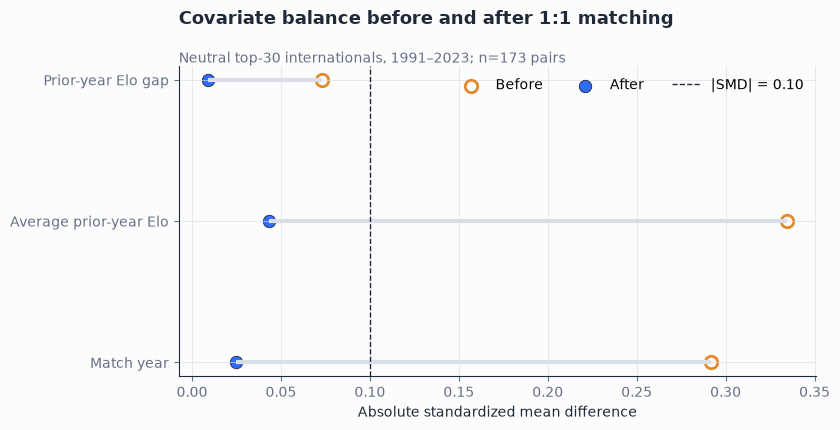

In [6]:
# Optimal 1:1 matching without replacement and balance diagnostics
MATCH_FEATURES = ["year", "avg_elo", "elo_gap"]

def standardized_mean_difference(left: pd.Series, right: pd.Series) -> float:
    denominator = math.sqrt((left.var(ddof=1) + right.var(ddof=1)) / 2)
    return 0.0 if denominator == 0 else float((left.mean() - right.mean()) / denominator)

def optimal_pair_match(
    frame: pd.DataFrame,
    left_label: str,
    right_label: str,
    *,
    caliper: float = 1.25,
    exact_neutral: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    pair_rows = []
    pair_id = 0
    groups = frame.groupby("neutral_bool", dropna=False) if exact_neutral else [("all", frame)]
    for _, stratum in groups:
        left = stratum[stratum["analysis_context"].eq(left_label)].copy()
        right = stratum[stratum["analysis_context"].eq(right_label)].copy()
        if left.empty or right.empty:
            continue
        center = pd.concat([left[MATCH_FEATURES], right[MATCH_FEATURES]]).mean()
        scale = pd.concat([left[MATCH_FEATURES], right[MATCH_FEATURES]]).std(ddof=0).replace(0, 1)
        left_matrix = ((left[MATCH_FEATURES] - center) / scale).to_numpy()
        right_matrix = ((right[MATCH_FEATURES] - center) / scale).to_numpy()
        costs = np.sqrt(((left_matrix[:, None, :] - right_matrix[None, :, :]) ** 2).sum(axis=2))
        left_idx, right_idx = linear_sum_assignment(costs)
        for left_pos, right_pos in zip(left_idx, right_idx):
            distance = float(costs[left_pos, right_pos])
            if distance > caliper:
                continue
            pair_id += 1
            left_row = left.iloc[left_pos].copy()
            right_row = right.iloc[right_pos].copy()
            left_row["pair_id"] = pair_id
            right_row["pair_id"] = pair_id
            left_row["match_distance"] = distance
            right_row["match_distance"] = distance
            pair_rows.extend([left_row, right_row])
    matched_long = pd.DataFrame(pair_rows)
    left_matched = matched_long[matched_long["analysis_context"].eq(left_label)].sort_values("pair_id")
    right_matched = matched_long[matched_long["analysis_context"].eq(right_label)].sort_values("pair_id")
    paired = pd.DataFrame({
        "pair_id": left_matched["pair_id"].to_numpy(),
        "friendly_goals": left_matched["total_goals"].to_numpy(),
        "official_goals": right_matched["total_goals"].to_numpy(),
        "distance": left_matched["match_distance"].to_numpy(),
    })
    return matched_long, paired

FRIENDLY = "Elite professional friendly"
OFFICIAL = "Official tournament match"
matched_primary, paired_primary = optimal_pair_match(primary_pool, FRIENDLY, OFFICIAL)
primary_friendly = matched_primary[matched_primary["analysis_context"].eq(FRIENDLY)].sort_values("pair_id")
primary_official = matched_primary[matched_primary["analysis_context"].eq(OFFICIAL)].sort_values("pair_id")

raw_friendly = primary_pool[primary_pool["analysis_context"].eq(FRIENDLY)]
raw_official = primary_pool[primary_pool["analysis_context"].eq(OFFICIAL)]
balance_rows = []
for feature in MATCH_FEATURES:
    balance_rows.append({
        "feature": feature,
        "before": standardized_mean_difference(raw_friendly[feature], raw_official[feature]),
        "after": standardized_mean_difference(primary_friendly[feature], primary_official[feature]),
    })
balance = pd.DataFrame(balance_rows)

assert len(paired_primary) >= 150
assert balance["after"].abs().max() < 0.10
matched_primary.to_csv(PROCESSED / "matched_neutral_elite_friendlies_vs_officials.csv", index=False)
balance.to_csv(TABLES / "v2_matching_balance.csv", index=False)

print(f"Matched neutral pairs: {len(paired_primary)}")
display(balance.assign(before_abs=balance["before"].abs(), after_abs=balance["after"].abs()).round(3))

fig, ax = plt.subplots(figsize=(8.5, 4.4))
y = np.arange(len(balance))
ax.hlines(y, balance["before"].abs(), balance["after"].abs(), color=GRID, linewidth=3)
ax.scatter(balance["before"].abs(), y, s=80, facecolor=BG, edgecolor=ORANGE, linewidth=2, label="Before")
ax.scatter(balance["after"].abs(), y, s=80, color=BLUE, edgecolor=INK, linewidth=0.6, label="After")
ax.axvline(0.10, color=INK, linestyle="--", linewidth=1, label="|SMD| = 0.10")
ax.set_yticks(y, ["Match year", "Average prior-year Elo", "Prior-year Elo gap"])
ax.set_xlabel("Absolute standardized mean difference")
ax.set_title("Covariate balance before and after 1:1 matching", loc="left", pad=30)
ax.text(0, 1.01, f"Neutral top-30 internationals, 1991–2023; n={len(paired_primary)} pairs", transform=ax.transAxes, color=MUTED)
ax.legend(loc="upper right", ncol=3)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(ASSETS / "v2_matching_balance.png", dpi=180, bbox_inches="tight")
plt.show()

,measure,value
0,Matched pairs,173.0000
1,Friendly mean goals,2.4509
2,Official mean goals,2.4913
3,Friendly − official mean difference,-0.0405
4,Bootstrap 95% CI low,-0.3526
5,Bootstrap 95% CI high,0.2659
6,Paired sign-flip permutation p,0.8240
7,Friendly five-plus rate,0.1214
8,Official five-plus rate,0.0867
9,Exact paired five-plus p,0.3449


,design,pairs,friendly_mean,official_mean,mean_difference,ci_low,ci_high,permutation_p
0,Neutral top-10,23,2.565,2.261,0.304,-0.391,1.000,0.472
1,Neutral top-15,55,2.418,2.418,0.000,-0.491,0.491,1.000
2,Neutral top-20,86,2.453,2.372,0.081,-0.314,0.477,0.726
3,Neutral top-30,173,2.451,2.491,-0.040,-0.364,0.254,0.825
4,Top-30 friendly vs qualifier,539,2.525,2.371,0.154,-0.039,0.351,0.127


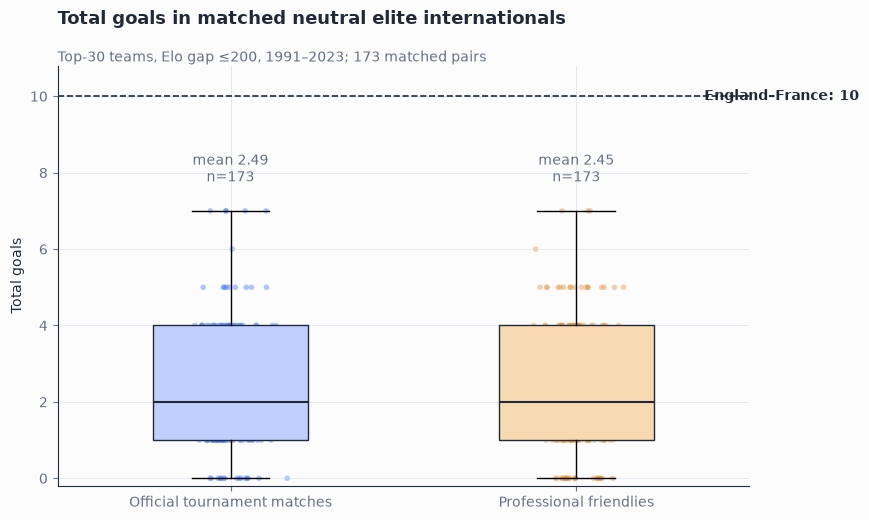

In [7]:
# Primary paired inference, five-goal threshold, and design sensitivities
def paired_inference(differences: np.ndarray, *, draws: int = 20_000, seed: int = SEED) -> dict[str, float]:
    local_rng = np.random.default_rng(seed)
    differences = np.asarray(differences, dtype=float)
    observed = float(differences.mean())
    bootstrap = np.array([
        local_rng.choice(differences, size=len(differences), replace=True).mean()
        for _ in range(draws)
    ])
    permutations = np.array([
        (differences * local_rng.choice([-1, 1], size=len(differences))).mean()
        for _ in range(draws)
    ])
    return {
        "mean_difference": observed,
        "ci_low": float(np.quantile(bootstrap, 0.025)),
        "ci_high": float(np.quantile(bootstrap, 0.975)),
        "permutation_p": float((np.sum(np.abs(permutations) >= abs(observed)) + 1) / (draws + 1)),
    }

primary_differences = paired_primary["friendly_goals"].to_numpy() - paired_primary["official_goals"].to_numpy()
primary_test = paired_inference(primary_differences)

friendly_high = paired_primary["friendly_goals"].ge(5).to_numpy()
official_high = paired_primary["official_goals"].ge(5).to_numpy()
friendly_only = int(np.sum(friendly_high & ~official_high))
official_only = int(np.sum(~friendly_high & official_high))
mcnemar_p = float(stats.binomtest(friendly_only, friendly_only + official_only, 0.5).pvalue)

primary_summary = pd.DataFrame([
    ("Matched pairs", len(paired_primary)),
    ("Friendly mean goals", paired_primary["friendly_goals"].mean()),
    ("Official mean goals", paired_primary["official_goals"].mean()),
    ("Friendly − official mean difference", primary_test["mean_difference"]),
    ("Bootstrap 95% CI low", primary_test["ci_low"]),
    ("Bootstrap 95% CI high", primary_test["ci_high"]),
    ("Paired sign-flip permutation p", primary_test["permutation_p"]),
    ("Friendly five-plus rate", friendly_high.mean()),
    ("Official five-plus rate", official_high.mean()),
    ("Exact paired five-plus p", mcnemar_p),
], columns=["measure", "value"])
display(primary_summary.round(4))

# Target-quality sensitivity: repeat neutral matching at stricter rank cutoffs.
rank_sensitivity = []
for rank_cutoff in (10, 15, 20, 30):
    pool = eligible[eligible["neutral_bool"] & eligible["worst_rank"].le(rank_cutoff)].copy()
    matched_rank, paired_rank = optimal_pair_match(pool, FRIENDLY, OFFICIAL)
    if paired_rank.empty:
        continue
    rank_result = paired_inference(
        paired_rank["friendly_goals"].to_numpy() - paired_rank["official_goals"].to_numpy(),
        draws=5_000,
        seed=SEED + rank_cutoff,
    )
    rank_sensitivity.append({
        "rank_cutoff": rank_cutoff,
        "pairs": len(paired_rank),
        "friendly_mean": paired_rank["friendly_goals"].mean(),
        "official_mean": paired_rank["official_goals"].mean(),
        **rank_result,
    })
rank_sensitivity = pd.DataFrame(rank_sensitivity)

# Extra-time sensitivity: use official qualifiers and exact-match venue status.
qualifier_names = {
    "FIFA World Cup qualification", "UEFA Euro qualification",
    "African Cup of Nations qualification", "AFC Asian Cup qualification",
    "Gold Cup qualification", "Oceania Nations Cup qualification",
    "Copa America qualification", "CONCACAF Nations League qualification",
}
qualifier_pool = complete[
    complete[["home_rating", "away_rating"]].notna().all(axis=1)
    & complete["worst_rank"].le(30)
    & complete["elo_gap"].le(200)
    & (complete["tournament_normalized"].eq("Friendly") | complete["tournament_normalized"].isin(qualifier_names))
].copy()
qualifier_pool["analysis_context"] = np.where(
    qualifier_pool["tournament_normalized"].eq("Friendly"), FRIENDLY, "Elite official qualifier"
)
_, paired_qualifier = optimal_pair_match(qualifier_pool, FRIENDLY, "Elite official qualifier")
qualifier_test = paired_inference(
    paired_qualifier["friendly_goals"].to_numpy() - paired_qualifier["official_goals"].to_numpy(),
    seed=SEED + 100,
)

sensitivity_table = pd.concat([
    rank_sensitivity.assign(design=lambda frame: "Neutral top-" + frame["rank_cutoff"].astype(str))[
        ["design", "pairs", "friendly_mean", "official_mean", "mean_difference", "ci_low", "ci_high", "permutation_p"]
    ],
    pd.DataFrame([{
        "design": "Top-30 friendly vs qualifier",
        "pairs": len(paired_qualifier),
        "friendly_mean": paired_qualifier["friendly_goals"].mean(),
        "official_mean": paired_qualifier["official_goals"].mean(),
        **qualifier_test,
    }]),
], ignore_index=True)
sensitivity_table.to_csv(TABLES / "v2_professional_control_sensitivity.csv", index=False)
display(sensitivity_table.round(3))

fig, ax = plt.subplots(figsize=(8.8, 5.3))
positions = [1, 2]
data = [paired_primary["official_goals"], paired_primary["friendly_goals"]]
box = ax.boxplot(data, positions=positions, widths=0.45, patch_artist=True, showfliers=False, medianprops={"color": INK, "linewidth": 1.5})
for patch, color in zip(box["boxes"], [BLUE_LIGHT, ORANGE_LIGHT]):
    patch.set_facecolor(color)
    patch.set_edgecolor(INK)
local_rng = np.random.default_rng(SEED)
for position, values, color in zip(positions, data, [BLUE, ORANGE]):
    jitter = local_rng.normal(0, 0.055, len(values))
    ax.scatter(np.full(len(values), position) + jitter, values, s=16, alpha=0.38, color=color, edgecolors="none")
    ax.text(position, 7.65, f"mean {np.mean(values):.2f}\nn={len(values)}", ha="center", va="bottom", color=MUTED)
ax.axhline(10, color=INK, linestyle="--", linewidth=1.2)
ax.text(2.37, 10, "England–France: 10", va="center", color=INK, fontweight="bold")
ax.set_xticks(positions, ["Official tournament matches", "Professional friendlies"])
ax.set_ylabel("Total goals")
ax.set_ylim(-0.2, 10.8)
ax.set_title("Total goals in matched neutral elite internationals", loc="left", pad=30)
ax.text(0, 1.01, f"Top-30 teams, Elo gap ≤200, 1991–2023; {len(paired_primary)} matched pairs", transform=ax.transAxes, color=MUTED)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(ASSETS / "v2_matched_goal_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

,context,matches,mean_goals,max_goals,empirical_10_plus,tail_model,tail_probability_pct
0,Matched official tournaments,173,2.4913,7.0,0.0000,Negative binomial,0.0275
1,Matched professional friendlies,173,2.4509,7.0,0.0000,Negative binomial,0.0761
5,2026 World Cup 1–102 · FIFA,102,2.9118,8.0,0.0000,Negative binomial,0.1138
3,World Cup third-place · all eras,20,3.8000,9.0,0.0000,Negative binomial,0.6170
2,World Cup title-path · all eras,226,3.1460,12.0,0.0088,Negative binomial,0.7773
4,Soccer Aid charity · regulation,15,5.1333,9.0,0.0000,Poisson,3.6925


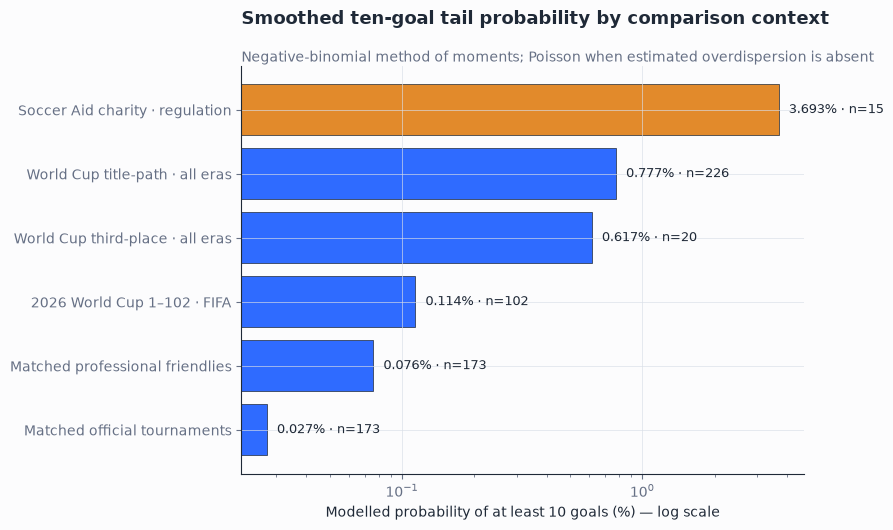

In [8]:
# Smoothed probability of a ten-goal match across contexts
men["total_goals"] = pd.to_numeric(men["home_team_score"]) + pd.to_numeric(men["away_team_score"])
title_path_stages = {"round of 16", "quarter-finals", "semi-finals", "final"}
world_cup_title = men.loc[men["stage_name"].isin(title_path_stages), "total_goals"].to_numpy()
world_cup_third = men.loc[men["stage_name"].eq("third-place match"), "total_goals"].to_numpy()
soccer_aid_goals = (soccer_aid["team_a_goals"] + soccer_aid["team_b_goals"]).to_numpy()

pmsr_match = pmsr.groupby("match_number").agg(
    total_goals=("goals", "sum"),
    total_xg=("xg", "sum"),
    attempts=("attempts_at_goal", "sum"),
    shots_on_target=("shots_on_target", "sum"),
    line_breaks=("completed_line_breaks", "sum"),
    pressures=("defensive_pressures", "sum"),
    direct_pressures=("direct_pressures", "sum"),
    forced_turnovers=("forced_turnovers", "sum"),
)
pmsr_match["turnovers_per_100_pressures"] = 100 * pmsr_match["forced_turnovers"] / pmsr_match["pressures"]
pmsr_match["direct_pressure_share_pct"] = 100 * pmsr_match["direct_pressures"] / pmsr_match["pressures"]
pmsr_match["goals_per_xg"] = pmsr_match["total_goals"] / pmsr_match["total_xg"]

def count_tail(values: np.ndarray, threshold: int = 10) -> dict[str, float | str]:
    values = np.asarray(values, dtype=float)
    mean = float(values.mean())
    variance = float(values.var(ddof=1))
    if variance <= mean * 1.001:
        tail = float(stats.poisson.sf(threshold - 1, mean))
        model = "Poisson"
        dispersion = 0.0
    else:
        dispersion = (variance - mean) / mean**2
        size = 1 / dispersion
        probability = size / (size + mean)
        tail = float(stats.nbinom.sf(threshold - 1, size, probability))
        model = "Negative binomial"
    return {
        "matches": len(values),
        "mean_goals": mean,
        "sd_goals": math.sqrt(variance),
        "empirical_10_plus": float(np.mean(values >= threshold)),
        "max_goals": float(values.max()),
        "tail_probability": tail,
        "tail_model": model,
        "dispersion": dispersion,
    }

tail_contexts = {
    "Matched official tournaments": paired_primary["official_goals"].to_numpy(),
    "Matched professional friendlies": paired_primary["friendly_goals"].to_numpy(),
    "World Cup title-path · all eras": world_cup_title,
    "World Cup third-place · all eras": world_cup_third,
    "Soccer Aid charity · regulation": soccer_aid_goals,
    "2026 World Cup 1–102 · FIFA": pmsr_match.loc[:102, "total_goals"].to_numpy(),
}
tail_table = pd.DataFrame([
    {"context": context, **count_tail(values)} for context, values in tail_contexts.items()
]).sort_values("tail_probability")
tail_table["tail_probability_pct"] = 100 * tail_table["tail_probability"]
tail_table.to_csv(TABLES / "v2_ten_goal_tail_probabilities.csv", index=False)
display(tail_table[["context", "matches", "mean_goals", "max_goals", "empirical_10_plus", "tail_model", "tail_probability_pct"]].round(4))

fig, ax = plt.subplots(figsize=(9.0, 5.4))
plot_tail = tail_table.sort_values("tail_probability", ascending=True).reset_index(drop=True)
colors = [ORANGE if "Soccer Aid" in name else BLUE for name in plot_tail["context"]]
bars = ax.barh(plot_tail["context"], plot_tail["tail_probability_pct"], color=colors, edgecolor=INK, linewidth=0.5)
ax.set_xscale("log")
ax.set_xlabel("Modelled probability of at least 10 goals (%) — log scale")
ax.set_title("Smoothed ten-goal tail probability by comparison context", loc="left", pad=30)
ax.text(0, 1.01, "Negative-binomial method of moments; Poisson when estimated overdispersion is absent", transform=ax.transAxes, color=MUTED)
for bar, probability, sample in zip(bars, plot_tail["tail_probability_pct"], plot_tail["matches"]):
    ax.text(probability * 1.10, bar.get_y() + bar.get_height()/2, f"{probability:.3f}% · n={sample}", va="center", fontsize=9, color=INK)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(ASSETS / "v2_predictive_tail.png", dpi=180, bbox_inches="tight")
plt.show()

,metric,label,current_value,earlier_median,earlier_min,earlier_max,percentile
0,total_goals,Goals,10.00,3.00,0.00,8.00,100.00
1,total_xg,Total xG,5.33,2.45,0.97,4.57,100.00
2,attempts,Attempts,38.00,24.00,11.00,41.00,95.10
3,shots_on_target,Shots on target,20.00,8.00,2.00,18.00,100.00
4,line_breaks,Completed line breaks,221.00,182.50,134.00,252.00,91.18
5,pressures,Defensive pressures,558.00,520.50,363.00,704.00,67.65
6,direct_pressures,Direct pressures,119.00,88.00,50.00,124.00,98.04
7,forced_turnovers,Forced turnovers,62.00,83.00,54.00,109.00,4.90
8,turnovers_per_100_pressures,Turnovers per 100 pressures,11.11,15.64,11.26,27.82,0.00


,team,retained_starters,starter_changes,retained_players
0,France,4,7,"Adrien Rabiot, Kylian Mbappe, Michael Olise, M..."
1,England,4,7,"Declan Rice, Djed Spence, Marc Guehi, Morgan R..."


current                                       \
metric                attempts_at_goal defensive_pressures direct_pressures   
team    prior_matches                                                         
England 7                         19.0               223.0             44.0   
France  7                         19.0               335.0             75.0   

                                                              \
metric                forced_turnovers shots_on_target    xg   
team    prior_matches                                          
England 7                         32.0            11.0  2.34   
France  7                         30.0             9.0  2.99   

                      prior_tournament_mean                      \
metric                     attempts_at_goal defensive_pressures   
team    prior_matches                                             
England 7                             14.14              244.00   
France  7                             17.14              233.86   

                                                                               
metric                direct_pressures forced_turnovers shots_on_target    xg  
team    prior_matches                                                          
England 7                        42.00            34.57            5.86  1.81  
France  7                        38.29            42.86            7.14  1.97

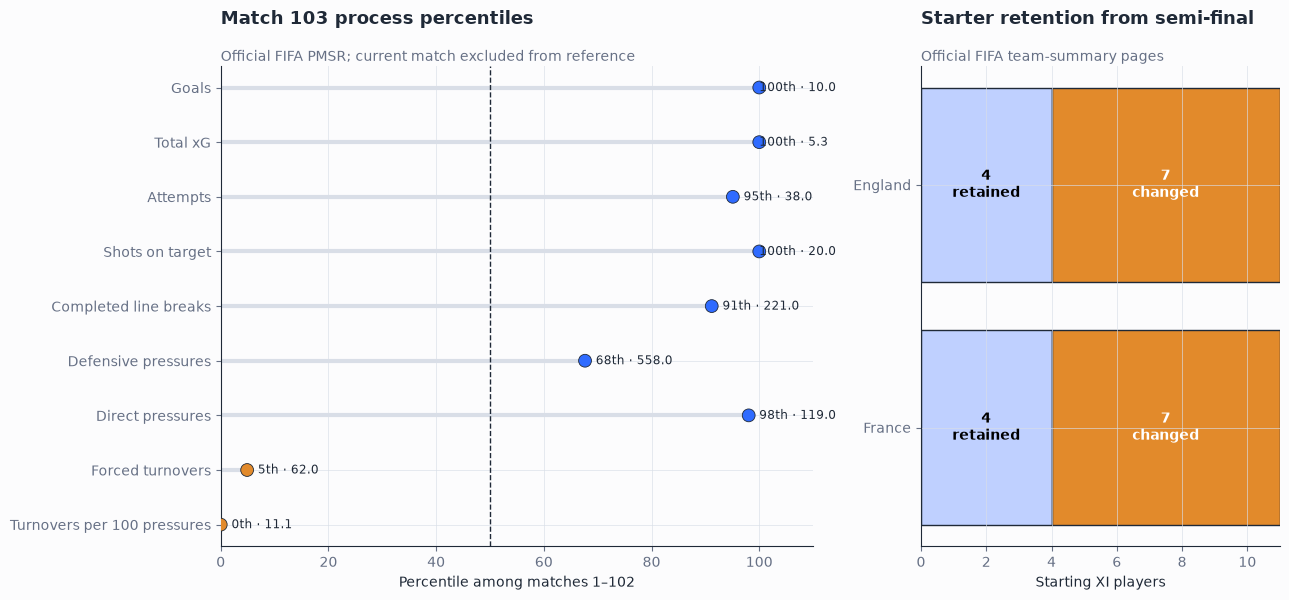

In [9]:
# Official FIFA process metrics and lineup rotation
current_process = pmsr_match.loc[103]
earlier_process = pmsr_match.loc[:102]
metric_labels = {
    "total_goals": "Goals",
    "total_xg": "Total xG",
    "attempts": "Attempts",
    "shots_on_target": "Shots on target",
    "line_breaks": "Completed line breaks",
    "pressures": "Defensive pressures",
    "direct_pressures": "Direct pressures",
    "forced_turnovers": "Forced turnovers",
    "turnovers_per_100_pressures": "Turnovers per 100 pressures",
}
process_rows = []
for metric, label in metric_labels.items():
    value = float(current_process[metric])
    process_rows.append({
        "metric": metric,
        "label": label,
        "current_value": value,
        "earlier_median": float(earlier_process[metric].median()),
        "earlier_min": float(earlier_process[metric].min()),
        "earlier_max": float(earlier_process[metric].max()),
        "percentile": 100 * float((earlier_process[metric] < value).mean()),
    })
process_percentiles = pd.DataFrame(process_rows)

rotation_rows = []
semifinal_match = {"France": 101, "England": 102}
for team in ("France", "England"):
    semifinal_starters = set(lineups.loc[(lineups["team"].eq(team)) & (lineups["match_number"].eq(semifinal_match[team])), "player"])
    third_place_starters = set(lineups.loc[(lineups["team"].eq(team)) & (lineups["match_number"].eq(103)), "player"])
    retained = sorted(semifinal_starters & third_place_starters)
    rotation_rows.append({
        "team": team,
        "retained_starters": len(retained),
        "starter_changes": 11 - len(retained),
        "retained_players": ", ".join(retained),
    })
rotation = pd.DataFrame(rotation_rows)
assert rotation["starter_changes"].eq(7).all()

team_process_rows = []
for team in ("France", "England"):
    prior = pmsr[(pmsr["team_name"].eq(team)) & pmsr["match_number"].lt(103)]
    current = pmsr[(pmsr["team_name"].eq(team)) & pmsr["match_number"].eq(103)].iloc[0]
    for metric in ("xg", "attempts_at_goal", "shots_on_target", "defensive_pressures", "direct_pressures", "forced_turnovers"):
        team_process_rows.append({
            "team": team,
            "metric": metric,
            "current": float(current[metric]),
            "prior_tournament_mean": float(prior[metric].mean()),
            "prior_matches": len(prior),
        })
team_process = pd.DataFrame(team_process_rows)

process_percentiles.to_csv(TABLES / "v2_fifa_process_percentiles.csv", index=False)
rotation.to_csv(TABLES / "v2_lineup_rotation.csv", index=False)
team_process.to_csv(TABLES / "v2_same_team_process.csv", index=False)
display(process_percentiles.round(2))
display(rotation)
display(team_process.pivot(index=["team", "prior_matches"], columns="metric", values=["current", "prior_tournament_mean"]).round(2))

fig, axes = plt.subplots(1, 2, figsize=(13.0, 6.1), gridspec_kw={"width_ratios": [1.65, 1]})
process_plot = process_percentiles.iloc[::-1].reset_index(drop=True)
y = np.arange(len(process_plot))
point_colors = [ORANGE if metric in {"forced_turnovers", "turnovers_per_100_pressures"} else BLUE for metric in process_plot["metric"]]
axes[0].hlines(y, 0, process_plot["percentile"], color=GRID, linewidth=3)
axes[0].scatter(process_plot["percentile"], y, s=85, c=point_colors, edgecolor=INK, linewidth=0.6, zorder=3)
axes[0].axvline(50, color=INK, linestyle="--", linewidth=1)
axes[0].set_yticks(y, process_plot["label"])
axes[0].set_xlim(0, 110)
axes[0].set_xlabel("Percentile among matches 1–102")
axes[0].set_title("Match 103 process percentiles", loc="left", pad=30)
axes[0].text(0, 1.01, "Official FIFA PMSR; current match excluded from reference", transform=axes[0].transAxes, color=MUTED)
for yi, percentile, value in zip(y, process_plot["percentile"], process_plot["current_value"]):
    axes[0].text(min(percentile + 2, 100), yi, f"{percentile:.0f}th · {value:.1f}", va="center", fontsize=8.5, color=INK)

teams = rotation["team"].tolist()
retained = rotation["retained_starters"].to_numpy()
changed = rotation["starter_changes"].to_numpy()
axes[1].barh(teams, retained, color=BLUE_LIGHT, edgecolor=INK, label="Retained")
axes[1].barh(teams, changed, left=retained, color=ORANGE, edgecolor=INK, label="Changed")
for idx, (keep, change) in enumerate(zip(retained, changed)):
    axes[1].text(keep / 2, idx, f"{keep}\nretained", ha="center", va="center", fontweight="bold")
    axes[1].text(keep + change / 2, idx, f"{change}\nchanged", ha="center", va="center", color="white", fontweight="bold")
axes[1].set_xlim(0, 11)
axes[1].set_xlabel("Starting XI players")
axes[1].set_title("Starter retention from semi-final", loc="left", pad=30)
axes[1].text(0, 1.01, "Official FIFA team-summary pages", transform=axes[1].transAxes, color=MUTED)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(ASSETS / "v2_fifa_process_and_rotation.png", dpi=180, bbox_inches="tight")
plt.show()

gap_bin,0,1,2,3+
time_bin,,,,
16–30,0.0248,0.0278,0.0399,0.0865
1–15,0.0239,0.0242,0.0449,0.0909
31–45,0.0250,0.0277,0.0405,0.0504
46–60,0.0282,0.0310,0.0303,0.0446
61–75,0.0266,0.0320,0.0427,0.0462
76–90,0.0349,0.0362,0.0419,0.0579


,scenario,goals,ci_low,ci_high
0,Level-state path,2.452,2.299,2.611
1,Observed score-state path,3.297,3.011,3.618
2,Actual England–France,10.000,NaN,NaN


,event,historical_matches,denominator,rate,rate_pct
0,At least four first-half goals,42,964,0.044,4.357
1,At least six second-half goals,7,964,0.007,0.726
2,At least ten regulation goals,4,964,0.004,0.415


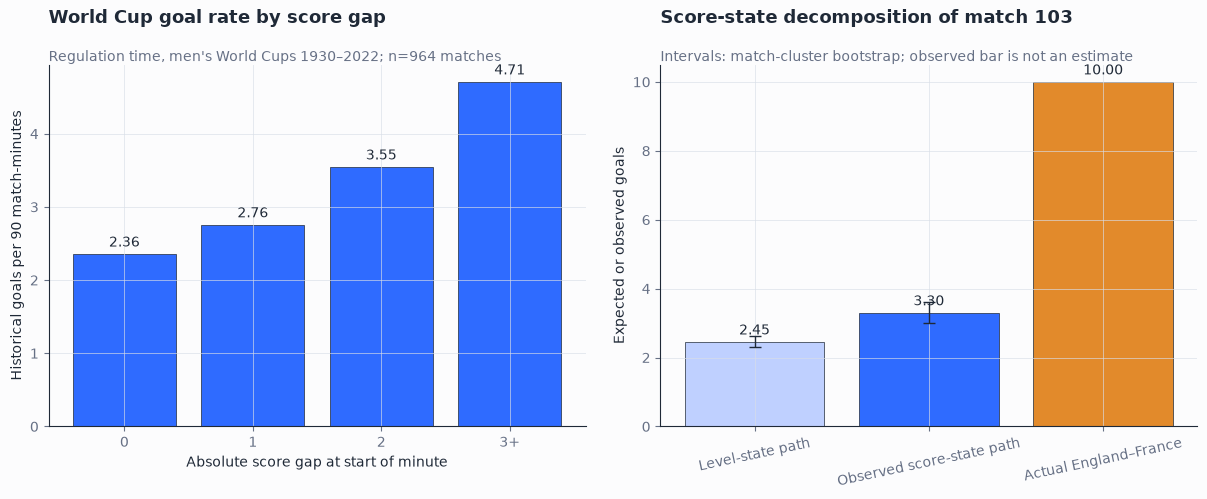

In [10]:
# Regulation-time score-state exposure and World Cup goal hazards
regulation_goals = men_goal_events[
    ~men_goal_events["match_period"].str.startswith("extra time", na=False)
].copy()
regulation_goals["minute"] = pd.to_numeric(regulation_goals["minute_regulation"], errors="coerce").clip(1, 90).astype(int)

event_map: defaultdict[str, defaultdict[int, list[str]]] = defaultdict(lambda: defaultdict(list))
for row in regulation_goals.itertuples():
    event_map[row.match_id][row.minute].append(row.team_name)

time_labels = ["1–15", "16–30", "31–45", "46–60", "61–75", "76–90"]
panel_rows = []
for match in men.itertuples():
    home_score = 0
    away_score = 0
    for minute in range(1, 91):
        absolute_gap = abs(home_score - away_score)
        gap_bin = "3+" if absolute_gap >= 3 else str(absolute_gap)
        goals_this_minute = event_map[match.match_id].get(minute, [])
        panel_rows.append((match.match_id, minute, time_labels[(minute - 1) // 15], gap_bin, len(goals_this_minute)))
        for scoring_team in goals_this_minute:
            if scoring_team == match.home_team_name:
                home_score += 1
            else:
                away_score += 1

score_panel = pd.DataFrame(panel_rows, columns=["match_id", "minute", "time_bin", "gap_bin", "goals"])
score_rates = score_panel.groupby(["time_bin", "gap_bin"], observed=True).agg(
    goals=("goals", "sum"), exposure_minutes=("goals", "size")
).reset_index()
score_rates["goals_per_minute"] = score_rates["goals"] / score_rates["exposure_minutes"]

current_goals["minute_int"] = np.floor(current_goals["minute_decimal"]).clip(1, 90).astype(int)
current_event_map: defaultdict[int, list[str]] = defaultdict(list)
for row in current_goals.itertuples():
    current_event_map[row.minute_int].append(row.team)

france_score = 0
england_score = 0
current_path_rows = []
for minute in range(1, 91):
    absolute_gap = abs(france_score - england_score)
    gap_bin = "3+" if absolute_gap >= 3 else str(absolute_gap)
    time_bin = time_labels[(minute - 1) // 15]
    goals_this_minute = current_event_map.get(minute, [])
    current_path_rows.append((minute, time_bin, gap_bin, len(goals_this_minute)))
    for scoring_team in goals_this_minute:
        if scoring_team == "France":
            france_score += 1
        else:
            england_score += 1

current_path = pd.DataFrame(current_path_rows, columns=["minute", "time_bin", "gap_bin", "observed_goals"])
current_path = current_path.merge(
    score_rates[["time_bin", "gap_bin", "goals_per_minute"]],
    on=["time_bin", "gap_bin"],
    validate="many_to_one",
)
level_path = current_path[["minute", "time_bin"]].merge(
    score_rates[score_rates["gap_bin"].eq("0")][["time_bin", "goals_per_minute"]],
    on="time_bin",
    validate="many_to_one",
)

# Cluster bootstrap by historical match using compact cell matrices.
cell_order = pd.MultiIndex.from_frame(score_rates[["time_bin", "gap_bin"]])
match_cell = score_panel.groupby(["match_id", "time_bin", "gap_bin"]).agg(
    goals=("goals", "sum"), exposure=("goals", "size")
)
goal_matrix = match_cell["goals"].unstack(["time_bin", "gap_bin"]).reindex(columns=cell_order, fill_value=0).fillna(0).to_numpy()
exposure_matrix = match_cell["exposure"].unstack(["time_bin", "gap_bin"]).reindex(columns=cell_order, fill_value=0).fillna(0).to_numpy()
current_cell_counts = current_path.groupby(["time_bin", "gap_bin"]).size().reindex(cell_order, fill_value=0).to_numpy()
level_cell_counts = pd.Series(0, index=cell_order, dtype=float)
for time_bin in time_labels:
    level_cell_counts.loc[(time_bin, "0")] = 15

bootstrap_counts = rng.multinomial(len(goal_matrix), np.repeat(1 / len(goal_matrix), len(goal_matrix)), size=5_000)
bootstrap_goals = bootstrap_counts @ goal_matrix
bootstrap_exposure = bootstrap_counts @ exposure_matrix
bootstrap_rates = np.divide(bootstrap_goals, bootstrap_exposure, out=np.zeros_like(bootstrap_goals, dtype=float), where=bootstrap_exposure > 0)
current_expected_boot = bootstrap_rates @ current_cell_counts
level_expected_boot = bootstrap_rates @ level_cell_counts.to_numpy()

current_expected = float(current_path["goals_per_minute"].sum())
level_expected = float(level_path["goals_per_minute"].sum())
state_increase = current_expected - level_expected

first_half_goals = regulation_goals[regulation_goals["minute"].le(45)].groupby("match_id").size().reindex(men["match_id"], fill_value=0)
second_half_goals = regulation_goals[regulation_goals["minute"].gt(45)].groupby("match_id").size().reindex(men["match_id"], fill_value=0)
rarity_table = pd.DataFrame([
    ("At least four first-half goals", int((first_half_goals >= 4).sum()), len(men), float((first_half_goals >= 4).mean())),
    ("At least six second-half goals", int((second_half_goals >= 6).sum()), len(men), float((second_half_goals >= 6).mean())),
    ("At least ten regulation goals", int(((first_half_goals + second_half_goals) >= 10).sum()), len(men), float(((first_half_goals + second_half_goals) >= 10).mean())),
], columns=["event", "historical_matches", "denominator", "rate"])

state_summary = pd.DataFrame([
    ("Level-state path", level_expected, *np.quantile(level_expected_boot, [0.025, 0.975])),
    ("Observed score-state path", current_expected, *np.quantile(current_expected_boot, [0.025, 0.975])),
    ("Actual England–France", 10.0, np.nan, np.nan),
], columns=["scenario", "goals", "ci_low", "ci_high"])
state_summary.to_csv(TABLES / "v2_score_state_decomposition.csv", index=False)
rarity_table.to_csv(TABLES / "v2_world_cup_regulation_rarity.csv", index=False)
score_rates.to_csv(TABLES / "v2_score_state_rates.csv", index=False)
display(score_rates.pivot(index="time_bin", columns="gap_bin", values="goals_per_minute").round(4))
display(state_summary.round(3))
display(rarity_table.assign(rate_pct=100 * rarity_table["rate"]).round(3))

aggregate_gap = score_panel.groupby("gap_bin").agg(goals=("goals", "sum"), exposure=("goals", "size")).reset_index()
aggregate_gap["goals_per_90"] = 90 * aggregate_gap["goals"] / aggregate_gap["exposure"]
gap_order = ["0", "1", "2", "3+"]
aggregate_gap["gap_bin"] = pd.Categorical(aggregate_gap["gap_bin"], gap_order, ordered=True)
aggregate_gap = aggregate_gap.sort_values("gap_bin")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.1))
bars = axes[0].bar(aggregate_gap["gap_bin"].astype(str), aggregate_gap["goals_per_90"], color=BLUE, edgecolor=INK, linewidth=0.5)
axes[0].set_xlabel("Absolute score gap at start of minute")
axes[0].set_ylabel("Historical goals per 90 match-minutes")
axes[0].set_title("World Cup goal rate by score gap", loc="left", pad=30)
axes[0].text(0, 1.01, f"Regulation time, men's World Cups 1930–2022; n={len(men)} matches", transform=axes[0].transAxes, color=MUTED)
axes[0].bar_label(bars, fmt="%.2f", padding=3, color=INK)

scenario_colors = [BLUE_LIGHT, BLUE, ORANGE]
scenario_bars = axes[1].bar(state_summary["scenario"], state_summary["goals"], color=scenario_colors, edgecolor=INK, linewidth=0.5)
error_low = state_summary["goals"] - state_summary["ci_low"]
error_high = state_summary["ci_high"] - state_summary["goals"]
axes[1].errorbar([0, 1], state_summary.loc[:1, "goals"], yerr=np.vstack([error_low[:2], error_high[:2]]), fmt="none", ecolor=INK, capsize=4, linewidth=1)
axes[1].set_ylabel("Expected or observed goals")
axes[1].set_title("Score-state decomposition of match 103", loc="left", pad=30)
axes[1].text(0, 1.01, "Intervals: match-cluster bootstrap; observed bar is not an estimate", transform=axes[1].transAxes, color=MUTED)
axes[1].tick_params(axis="x", rotation=12)
axes[1].bar_label(scenario_bars, fmt="%.2f", padding=3, color=INK)
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(ASSETS / "v2_score_state_decomposition.png", dpi=180, bbox_inches="tight")
plt.show()

In [11]:
# Evidence scorecard and machine-readable handoff
evidence_scorecard = pd.DataFrame([
    ("Lower selection priority", "Supported", "Each team changed 7 of 11 semi-final starters."),
    ("Elite friendlies normally score much more", "Not supported", f"Matched difference {primary_test['mean_difference']:+.2f}; 95% CI {primary_test['ci_low']:+.2f} to {primary_test['ci_high']:+.2f}; p={primary_test['permutation_p']:.3f}."),
    ("Charity-like scoring spectacle", "Supported descriptively", "Ten goals exceeded every matched neutral professional comparison and every Soccer Aid row in the saved benchmark."),
    ("Teams made no defensive effort", "Contradicted", f"Direct pressures were at the {process_percentiles.loc[process_percentiles['metric'].eq('direct_pressures'), 'percentile'].iloc[0]:.0f}th percentile."),
    ("Defensive control was unusually ineffective", "Supported", f"Only {current_process['forced_turnovers']:.0f} turnovers and {current_process['turnovers_per_100_pressures']:.1f} per 100 pressures; the latter was below all 102 earlier matches."),
    ("The 4–0 state explains all ten goals", "Contradicted", f"State-conditioned expectation {current_expected:.2f} versus 10 observed; level-state expectation {level_expected:.2f}."),
    ("Current match fits an ordinary elite friendly", "Not supported", "Ten-goal model tail is below 0.1% in both matched professional contexts."),
], columns=["claim", "assessment", "evidence"])
display(evidence_scorecard)

summary_payload = {
    "analysis_as_of": "2026-07-19",
    "primary_matched_pairs": int(len(paired_primary)),
    "primary_friendly_mean_goals": float(paired_primary["friendly_goals"].mean()),
    "primary_official_mean_goals": float(paired_primary["official_goals"].mean()),
    "primary_mean_difference": float(primary_test["mean_difference"]),
    "primary_ci_low": float(primary_test["ci_low"]),
    "primary_ci_high": float(primary_test["ci_high"]),
    "primary_permutation_p": float(primary_test["permutation_p"]),
    "primary_mcnemar_p": mcnemar_p,
    "france_starter_changes": int(rotation.loc[rotation["team"].eq("France"), "starter_changes"].iloc[0]),
    "england_starter_changes": int(rotation.loc[rotation["team"].eq("England"), "starter_changes"].iloc[0]),
    "current_total_xg": float(current_process["total_xg"]),
    "current_shots_on_target": int(current_process["shots_on_target"]),
    "current_direct_pressures": int(current_process["direct_pressures"]),
    "current_forced_turnovers": int(current_process["forced_turnovers"]),
    "current_turnovers_per_100_pressures": float(current_process["turnovers_per_100_pressures"]),
    "level_state_expected_goals": level_expected,
    "observed_state_expected_goals": current_expected,
    "observed_goals": 10,
}
with open(TABLES / "v2_summary_metrics.json", "w", encoding="utf-8") as handle:
    json.dump(summary_payload, handle, indent=2)
evidence_scorecard.to_csv(TABLES / "v2_evidence_scorecard.csv", index=False)
quality_checks.to_csv(TABLES / "v2_data_quality_checks.csv", index=False)

print("Saved analysis tables:", TABLES)
print("Saved figures:", ASSETS)

,claim,assessment,evidence
0,Lower selection priority,Supported,Each team changed 7 of 11 semi-final starters.
1,Elite friendlies normally score much more,Not supported,Matched difference -0.04; 95% CI -0.35 to +0.2...
2,Charity-like scoring spectacle,Supported descriptively,Ten goals exceeded every matched neutral profe...
3,Teams made no defensive effort,Contradicted,Direct pressures were at the 98th percentile.
4,Defensive control was unusually ineffective,Supported,Only 62 turnovers and 11.1 per 100 pressures; ...
5,The 4–0 state explains all ten goals,Contradicted,State-conditioned expectation 3.30 versus 10 o...
6,Current match fits an ordinary elite friendly,Not supported,Ten-goal model tail is below 0.1% in both matc...


Saved analysis tables: C:\Users\miqba\projects\Match Analyzer\output\tables
Saved figures: C:\Users\miqba\projects\Match Analyzer\output\assets


## Takeaways

1. **The stronger professional sample removes the original power problem for the friendly comparison.** With 173 neutral matched pairs, there is no evidence of a large general scoring difference between elite friendlies and official tournament matches. The result remains small and unstable across stricter rank cutoffs.
2. **Selection clearly signalled lower priority.** Both teams replaced seven semi-final starters, consistent with fatigue management, experimentation, and reduced consequence.
3. **The game was open from process, not merely scoreline luck.** It exceeded every earlier 2026 match in total xG and shots on target.
4. **Effort and control separated.** Direct pressing was exceptionally high, while forced-turnover yield was exceptionally low. The teams appeared to attack and press aggressively without maintaining normal defensive control.
5. **Game state amplified the spectacle.** The 4–0 lead raised the historical scoring expectation by roughly one-third, but the state-conditioned expectation remained far below ten.
6. **Soccer Aid is still useful only as a visual anchor.** The current match was more extreme than the saved charity sample, but that does not make the competitions equivalent.

### Final interpretation

The evidence supports calling England–France a **lower-stakes, heavily rotated official match with exhibition-like openness**. It does not support the stronger claim that the players made no defensive effort. A better description is **high attacking commitment, aggressive pressing, weak pressure outcomes, and unusually permissive defensive structure**, intensified by the 4–0 game state.

### Remaining data gap

A same-provider event dataset covering elite professional friendlies would allow direct classification on pressure, transition, and defensive-structure features. The public score backbone supplies statistical power, but not those event-level behaviours. Other competitions' placement games also need a reliable stage-labelled source before hierarchical pooling is defensible.